# Low-Resolution Moderate-Advection Hybrid Vecchia Simulation

Focused low-resolution check for a practical advection-aware conditioning strategy when the true advection is stronger than the weak `-0.10` case.

Design:

- true `advec_lon = -0.16`, so the physical upstream lag-1 center is eastward by `0.16` degrees.
- `BaseLocal_A20_B18_C15`: original local structure baseline, using same-location anchors plus local lag neighbors.
- `FreshShift_A20_B18_C15`: pure shifted-center diagnostics with the same nominal 20/18/15 budget.
- `Hybrid_*`: same-location anchor plus a controlled mix of local lag neighbors and fresh shifted-center neighbors.

Shortlist tested:

- `BaseLocal_A20_B18_C15`
- `FreshShift_A20_B18_C15_O0p000` / `O0p126` / `O0p252`
- `Hybrid_NearLocal_L16F02_C12F02_O0p000` / `O0p060` / `O0p126` / `O0p252`
- `Hybrid_Lean_L08F04_C4F03_O0p000` / `O0p060` / `O0p126` / `O0p252`
- `Hybrid_TinyBalanced_L06F04_C3F03_O0p000` / `O0p060` / `O0p126` / `O0p252`

The true lag-1 shift is `0.16`; this notebook stress-tests no shift (`0.00`), near no-shift/half-cell edge (`0.06`), one-cell shift (`0.126`), and excessive over-shift (`0.252`, about two low-res lon cells).


In [12]:
import os
import sys
import time
import io
import contextlib
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.fft
import matplotlib.pyplot as plt

AMAREL_SRC = "/home/jl2815/tco"
LOCAL_SRC = "/Users/joonwonlee/Documents/GEMS_TCO-1/src"
_src = AMAREL_SRC if os.path.exists(AMAREL_SRC) else LOCAL_SRC
sys.path.insert(0, _src)

from GEMS_TCO import kernels_vecchia
from GEMS_TCO import kernels_vecchia_advec
from GEMS_TCO import orderings as _orderings

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64

# Low-resolution shift-center nearest-neighbor test: lat x4, lon x2.
DELTA_LAT = 0.044 * 4
DELTA_LON = 0.063 * 2
T_STEPS = 8

print("DEVICE:", DEVICE)
print("SRC:", _src)
print("Grid resolution:", DELTA_LAT, DELTA_LON)



DEVICE: cpu
SRC: /Users/joonwonlee/Documents/GEMS_TCO-1/src
Grid resolution: 0.176 0.126


## Settings And Realistic Hybrid Candidate Grid


In [13]:
LAT_RANGE = (-3.0, 2.0)
LON_RANGE = (121.0, 131.0)
MC_NUM_ITERS = 10  # raise to 30+ once the shortlist is clear
SEED = 42

SMOOTH = 0.5
MM_COND_NUMBER = 100
NHEADS = 0
DAILY_STRIDE = 2

LBFGS_STEPS = 5
LBFGS_EVAL = 20
LBFGS_HIST = 10
INIT_NOISE = 0.7
SUPPRESS_FIT_PRINTS = True

RUN_ONE_SHOT_GODAMBE = True
HESSIAN_EPS = 1e-4
SCORE_EPS = 1e-5
H_RIDGE_SCALE = 1e-6
GODAMBE_J_METHOD = "block"
GODAMBE_BLOCK_LAT_WIDTH = 0.50
GODAMBE_BLOCK_LON_WIDTH = 0.50
GODAMBE_BLOCK_TIME_WIDTH = 2.0

BASE_TRUE_DICT = {
    "sigmasq": 10.0,
    "range_lat": 0.30,
    "range_lon": 0.40,
    "range_time": 2.0,
    "advec_lat": 0.08,
    "nugget": 2.5,
}

# Moderate east-upstream case: stronger than the weak realistic -0.10 run.
TRUE_ADVEC_LON_LIST = [-0.16]
DEFAULT_TRUE_ADVEC_LON = -0.16
TRUE_DICT = {**BASE_TRUE_DICT, "advec_lon": DEFAULT_TRUE_ADVEC_LON}

BASE_A = 20
LOCAL_BEST_B, LOCAL_BEST_C = 18, 15

# Positive values are eastward lag-1 offsets used by shifted-center candidates.
# The truth is 0.16. These settings stress-test no shift, under-shift, and over-shift misspecification.
FRESH_SHIFT_DIAGNOSTIC_OFFSETS = [0.00, 0.126, 0.252]
HYBRID_LAG1_LON_OFFSETS = [0.00, 0.06, 0.126, 0.252]
PRED_LAG1_LON_OFFSETS = sorted(set(FRESH_SHIFT_DIAGNOSTIC_OFFSETS + HYBRID_LAG1_LON_OFFSETS))

# name, lag1 local, lag1 fresh, lag2 local, lag2 fresh
HYBRID_COUNT_GRID = [
    ("NearLocal_L16F02_C12F02", 16, 2, 12, 2),
    ("Lean_L08F04_C4F03", 8, 4, 4, 3),
    ("TinyBalanced_L06F04_C3F03", 6, 4, 3, 3),
]

print(f"lon step = {DELTA_LON:.3f}")
print("true advec_lon values:", TRUE_ADVEC_LON_LIST)
print("fresh-shift diagnostic offsets:", FRESH_SHIFT_DIAGNOSTIC_OFFSETS)
print("hybrid lag-1 eastward offsets:", HYBRID_LAG1_LON_OFFSETS)
print("all predicted offsets in lon cells:", [round(x / DELTA_LON, 3) for x in PRED_LAG1_LON_OFFSETS])


def make_true_dict(advec_lon):
    return {**BASE_TRUE_DICT, "advec_lon": float(advec_lon)}


def offset_tag(x):
    sign = "p" if x >= 0 else "m"
    return sign + f"{abs(float(x)):.3f}".replace(".", "p")


def total_conditioning_local(a, b=0, c=0, uses_lag2=True):
    total = int(a) + int(1 + b)
    if uses_lag2:
        total += int(1 + c)
    return total


def total_conditioning_hybrid(a, b_local=0, b_fresh=0, c_local=0, c_fresh=0, uses_lag2=True):
    total = int(a) + int(1 + b_local + b_fresh)
    if uses_lag2:
        total += int(1 + c_local + c_fresh)
    return total


def std_spec(name, a, b, c, group, allocation, daily_stride=DAILY_STRIDE, uses_lag2=True):
    return {
        "name": name,
        "group": group,
        "kernel": "std",
        "limit_A": int(a),
        "limit_B": int(b),
        "limit_C": int(c),
        "lag1_local_count": int(b),
        "lag1_fresh_count": 0,
        "lag2_local_count": int(c),
        "lag2_fresh_count": 0,
        "daily_stride": int(daily_stride),
        "uses_lag2": bool(uses_lag2),
        "pred_lag1_lon_offset": 0.0,
        "lag1_lon_shift": 0.0,
        "lag2_lon_shift": 0.0,
        "lag1_ratio_actual": float(b / a) if a else np.nan,
        "lag2_ratio_actual": float(c / a) if (a and uses_lag2) else 0.0,
        "total_conditioning": total_conditioning_local(a, b, c, uses_lag2=uses_lag2),
        "allocation": allocation,
        "description": f"t: {a}; t-1: same loc + {b} local; t-2: same loc + {c} local",
    }


def fresh_shift_spec(name, a, b_fresh, c_fresh, pred_lag1_offset, group, allocation):
    tag = offset_tag(pred_lag1_offset)
    full_name = f"{name}_O{tag}"
    return {
        "name": full_name,
        "group": group,
        "kernel": "fresh_shift",
        "limit_A": int(a),
        "limit_B": 0,
        "limit_C": 0,
        "lag1_local_count": 0,
        "lag1_fresh_count": int(b_fresh),
        "lag2_local_count": 0,
        "lag2_fresh_count": int(c_fresh),
        "daily_stride": DAILY_STRIDE,
        "uses_lag2": True,
        "pred_lag1_lon_offset": float(pred_lag1_offset),
        "lag1_lon_shift": float(pred_lag1_offset),
        "lag2_lon_shift": float(2.0 * pred_lag1_offset),
        "pred_lag1_cells": float(pred_lag1_offset / DELTA_LON),
        "pred_lag2_cells": float(2.0 * pred_lag1_offset / DELTA_LON),
        "lag1_ratio_actual": float(b_fresh / a) if a else np.nan,
        "lag2_ratio_actual": float(c_fresh / a) if a else np.nan,
        "total_conditioning": total_conditioning_hybrid(a, 0, b_fresh, 0, c_fresh, uses_lag2=True),
        "allocation": allocation,
        "description": f"t: {a}; t-1: same loc + {b_fresh} fresh shifted-center; t-2: same loc + {c_fresh} fresh shifted-center",
    }


def hybrid_spec(label, a, b_local, b_fresh, c_local, c_fresh, pred_lag1_offset, group="hybrid_budget_sweep"):
    tag = offset_tag(pred_lag1_offset)
    name = f"Hybrid_{label}_O{tag}"
    return {
        "name": name,
        "group": group,
        "kernel": "hybrid_fresh",
        "limit_A": int(a),
        "limit_B": int(b_local),
        "limit_C": int(c_local),
        "lag1_local_count": int(b_local),
        "lag1_fresh_count": int(b_fresh),
        "lag2_local_count": int(c_local),
        "lag2_fresh_count": int(c_fresh),
        "daily_stride": DAILY_STRIDE,
        "uses_lag2": True,
        "pred_lag1_lon_offset": float(pred_lag1_offset),
        "lag1_lon_shift": float(pred_lag1_offset),
        "lag2_lon_shift": float(2.0 * pred_lag1_offset),
        "pred_lag1_cells": float(pred_lag1_offset / DELTA_LON),
        "pred_lag2_cells": float(2.0 * pred_lag1_offset / DELTA_LON),
        "lag1_ratio_actual": float((b_local + b_fresh) / a) if a else np.nan,
        "lag2_ratio_actual": float((c_local + c_fresh) / a) if a else np.nan,
        "total_conditioning": total_conditioning_hybrid(a, b_local, b_fresh, c_local, c_fresh, uses_lag2=True),
        "allocation": f"B=same+local{b_local}+fresh{b_fresh}; C=same+local{c_local}+fresh{c_fresh}; offset={pred_lag1_offset:.3f}",
        "description": f"t: {a}; t-1: same loc + local {b_local} + fresh shift {b_fresh}; t-2: same loc + local {c_local} + fresh shift {c_fresh}",
    }


def build_model_specs():
    specs = []
    specs.append(std_spec(
        "BaseLocal_A20_B18_C15", BASE_A, LOCAL_BEST_B, LOCAL_BEST_C,
        "local_baseline", "original local-structure baseline: 20/18/15",
    ))
    for offset in FRESH_SHIFT_DIAGNOSTIC_OFFSETS:
        specs.append(fresh_shift_spec(
            "FreshShift_A20_B18_C15", BASE_A, 18, 15, offset,
            "fresh_shift_baseline", "pure fresh shifted-center baseline: 20/18/15",
        ))
    for label, b_local, b_fresh, c_local, c_fresh in HYBRID_COUNT_GRID:
        for offset in HYBRID_LAG1_LON_OFFSETS:
            specs.append(hybrid_spec(label, BASE_A, b_local, b_fresh, c_local, c_fresh, offset))
    return {f"{spec['group']}::{spec['name']}": spec for spec in specs}


MODEL_SPECS = build_model_specs()
spec_df = pd.DataFrame(MODEL_SPECS).T
print("True-advection scenarios:", len(TRUE_ADVEC_LON_LIST))
print("Number of model fits per scenario:", len(MODEL_SPECS))
print("Total fits per MC iteration:", len(TRUE_ADVEC_LON_LIST) * len(MODEL_SPECS))
display(spec_df[[
    "group", "kernel", "limit_A", "limit_B", "limit_C",
    "lag1_local_count", "lag1_fresh_count", "lag2_local_count", "lag2_fresh_count",
    "pred_lag1_lon_offset", "pred_lag1_cells", "lag1_lon_shift", "lag2_lon_shift",
    "daily_stride", "allocation", "lag1_ratio_actual", "lag2_ratio_actual", "total_conditioning", "description",
]])


lon step = 0.126
true advec_lon values: [-0.16]
fresh-shift diagnostic offsets: [0.0, 0.126, 0.252]
hybrid lag-1 eastward offsets: [0.0, 0.06, 0.126, 0.252]
all predicted offsets in lon cells: [0.0, 0.476, 1.0, 2.0]
True-advection scenarios: 1
Number of model fits per scenario: 16
Total fits per MC iteration: 16


,group,kernel,limit_A,limit_B,limit_C,lag1_local_count,lag1_fresh_count,lag2_local_count,lag2_fresh_count,pred_lag1_lon_offset,pred_lag1_cells,lag1_lon_shift,lag2_lon_shift,daily_stride,allocation,lag1_ratio_actual,lag2_ratio_actual,total_conditioning,description
local_baseline::BaseLocal_A20_B18_C15,local_baseline,std,20,18,15,18,0,15,0,0.0,NaN,0.0,0.0,2,original local-structure baseline: 20/18/15,0.9,0.75,55,t: 20; t-1: same loc + 18 local; t-2: same loc...
fresh_shift_baseline::FreshShift_A20_B18_C15_Op0p000,fresh_shift_baseline,fresh_shift,20,0,0,0,18,0,15,0.0,0.0,0.0,0.0,2,pure fresh shifted-center baseline: 20/18/15,0.9,0.75,55,t: 20; t-1: same loc + 18 fresh shifted-center...
fresh_shift_baseline::FreshShift_A20_B18_C15_Op0p126,fresh_shift_baseline,fresh_shift,20,0,0,0,18,0,15,0.126,1.0,0.126,0.252,2,pure fresh shifted-center baseline: 20/18/15,0.9,0.75,55,t: 20; t-1: same loc + 18 fresh shifted-center...
fresh_shift_baseline::FreshShift_A20_B18_C15_Op0p252,fresh_shift_baseline,fresh_shift,20,0,0,0,18,0,15,0.252,2.0,0.252,0.504,2,pure fresh shifted-center baseline: 20/18/15,0.9,0.75,55,t: 20; t-1: same loc + 18 fresh shifted-center...
hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C12F02_Op0p000,hybrid_budget_sweep,hybrid_fresh,20,16,12,16,2,12,2,0.0,0.0,0.0,0.0,2,B=same+local16+fresh2; C=same+local12+fresh2; ...,0.9,0.7,54,t: 20; t-1: same loc + local 16 + fresh shift ...
hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C12F02_Op0p060,hybrid_budget_sweep,hybrid_fresh,20,16,12,16,2,12,2,0.06,0.47619,0.06,0.12,2,B=same+local16+fresh2; C=same+local12+fresh2; ...,0.9,0.7,54,t: 20; t-1: same loc + local 16 + fresh shift ...
hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C12F02_Op0p126,hybrid_budget_sweep,hybrid_fresh,20,16,12,16,2,12,2,0.126,1.0,0.126,0.252,2,B=same+local16+fresh2; C=same+local12+fresh2; ...,0.9,0.7,54,t: 20; t-1: same loc + local 16 + fresh shift ...
hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C12F02_Op0p252,hybrid_budget_sweep,hybrid_fresh,20,16,12,16,2,12,2,0.252,2.0,0.252,0.504,2,B=same+local16+fresh2; C=same+local12+fresh2; ...,0.9,0.7,54,t: 20; t-1: same loc + local 16 + fresh shift ...
hybrid_budget_sweep::Hybrid_Lean_L08F04_C4F03_Op0p000,hybrid_budget_sweep,hybrid_fresh,20,8,4,8,4,4,3,0.0,0.0,0.0,0.0,2,B=same+local8+fresh4; C=same+local4+fresh3; of...,0.6,0.35,41,t: 20; t-1: same loc + local 8 + fresh shift 4...
hybrid_budget_sweep::Hybrid_Lean_L08F04_C4F03_Op0p060,hybrid_budget_sweep,hybrid_fresh,20,8,4,8,4,4,3,0.06,0.47619,0.06,0.12,2,B=same+local8+fresh4; C=same+local4+fresh3; of...,0.6,0.35,41,t: 20; t-1: same loc + local 8 + fresh shift 4...


## Boundary-Aware Fresh-Shift Hybrid Kernel


In [14]:
class fit_vecchia_lbfgs_fresh_hybrid(kernels_vecchia.fit_vecchia_lbfgs):
    """Vecchia kernel mixing local lag neighbors with fresh shifted-center lag neighbors.

    At each lag, the set is:
      same-location anchor + local NN around current location + fresh NN around shifted center.

    `lag*_fresh_count` includes the shifted center itself as the first candidate, then
    max-min NN around that shifted center.  If the shifted center leaves the observed
    longitude range, it falls back to the same local index; duplicate points are skipped
    and later NN candidates backfill the requested count whenever possible.
    """

    def __init__(
        self,
        smooth,
        input_map,
        nns_map,
        mm_cond_number,
        nheads,
        limit_A=20,
        limit_B=10,
        limit_C=6,
        daily_stride=2,
        spatial_coords=None,
        lag1_lon_offset=0.126,
        lag1_fresh_count=6,
        lag2_fresh_count=4,
    ):
        super().__init__(
            smooth,
            input_map,
            nns_map,
            mm_cond_number,
            nheads,
            limit_A=limit_A,
            limit_B=limit_B,
            limit_C=limit_C,
            daily_stride=daily_stride,
        )
        self.spatial_coords = spatial_coords
        self.lag1_lon_offset = float(abs(lag1_lon_offset))
        self.lag1_fresh_count = int(lag1_fresh_count)
        self.lag2_fresh_count = int(lag2_fresh_count)

    def _spatial_coords_np(self, n_points):
        if self.spatial_coords is not None:
            coords_np = np.asarray(self.spatial_coords[:n_points], dtype=np.float64)
        else:
            all_data = [torch.from_numpy(d) if isinstance(d, np.ndarray) else d for d in self.input_map.values()]
            coords_np = all_data[0][:n_points, :2].cpu().numpy().astype(np.float64)
        coords_np = coords_np.copy()
        nan_mask = np.isnan(coords_np).any(axis=1)
        coords_np[nan_mask] = np.array([0.0, 1000.0])
        return coords_np

    def _build_shift_lookup(self, n_points, multiplier):
        from sklearn.neighbors import BallTree

        coords_np = self._spatial_coords_np(n_points)
        tree = BallTree(np.radians(coords_np), metric="haversine")
        lats = coords_np[:, 0]
        lons = coords_np[:, 1]
        valid = ~np.isnan(coords_np).any(axis=1)
        lon_min = float(np.nanmin(lons[valid]))
        lon_max = float(np.nanmax(lons[valid]))
        base_ids = np.arange(n_points, dtype=np.int64)

        target_lons = lons + multiplier * self.lag1_lon_offset
        outside = (~valid) | (target_lons < lon_min) | (target_lons > lon_max)
        query = np.column_stack([np.radians(lats), np.radians(target_lons)])
        _, idx = tree.query(query, k=1)
        lookup = idx.flatten().astype(np.int64)
        lookup[outside] = base_ids[outside]
        return lookup

    def precompute_conditioning_sets(self):
        limit_A = int(self.limit_A)
        lag1_local = int(self.limit_B)
        lag2_local = int(self.limit_C)
        lag1_fresh = int(self.lag1_fresh_count)
        lag2_fresh = int(self.lag2_fresh_count)
        daily_stride = int(self.daily_stride)

        max_dim_A = limit_A
        max_dim_AB = limit_A + 1 + lag1_local + lag1_fresh
        max_dim_ABC = max_dim_AB + 1 + lag2_local + lag2_fresh

        n_stored = next((len(m) for m in self.nns_map if len(m) > 0), 0)
        print(
            "Pre-computing FreshHybrid Vecchia "
            f"[A={max_dim_A}, AB={max_dim_AB}, ABC={max_dim_ABC}, "
            f"B=local{lag1_local}+fresh{lag1_fresh}, "
            f"C=local{lag2_local}+fresh{lag2_fresh}, "
            f"lag1_offset={self.lag1_lon_offset:.4f}, stored={n_stored}]...",
            end=" ",
        )

        all_data_list = [torch.from_numpy(d) if isinstance(d, np.ndarray) else d for d in self.input_map.values()]
        Real_Data = torch.cat(all_data_list, dim=0).to(self.device, dtype=torch.float32)
        n_real, num_cols = Real_Data.shape

        is_nan_real = torch.isnan(Real_Data[:, 2])
        valid_lats = Real_Data[~is_nan_real, 0]
        self.lat_mean_val = valid_lats.mean().item() if valid_lats.numel() > 0 else Real_Data[:, 0].mean().item()
        print(f"[Mean Lat: {self.lat_mean_val:.4f}]", end=" ")
        is_nan_mask_np = is_nan_real.cpu().numpy()

        n_dummies = max_dim_ABC
        dummy_block = torch.zeros((n_dummies, num_cols), device=self.device, dtype=torch.float32)
        for k in range(n_dummies):
            dummy_block[k, 0] = (k + 1) * 1e8
            dummy_block[k, 1] = (k + 1) * 1e8
            dummy_block[k, 3] = (k + 1) * 1e8
        Full_Data = torch.cat([Real_Data, dummy_block], dim=0)
        dummy_start = n_real
        is_nan_mask_np = np.append(is_nan_mask_np, np.zeros(n_dummies, dtype=bool))

        key_list = list(self.input_map.keys())
        day_lengths = [len(d) for d in all_data_list]
        cumulative_len = np.cumsum([0] + day_lengths)
        n_time_steps = len(key_list)
        use_set_C = daily_stride < n_time_steps

        n_pts_per_day = day_lengths[0]
        lag1_center = self._build_shift_lookup(n_pts_per_day, multiplier=1.0)
        lag2_center = self._build_shift_lookup(n_pts_per_day, multiplier=2.0)

        heads_indices = []
        batch_list_A = []
        batch_list_AB = []
        batch_list_ABC = []

        def add_valid_neighbors(indices_to_check, current_indices, cap):
            count = 0
            for idx in indices_to_check:
                if count >= cap:
                    break
                idx = int(idx)
                if idx not in current_indices and not is_nan_mask_np[idx]:
                    current_indices.append(idx)
                    count += 1

        for time_idx, key in enumerate(key_list):
            day_len = day_lengths[time_idx]
            offset = cumulative_len[time_idx]

            for local_idx in range(min(day_len, self.nheads)):
                idx = offset + local_idx
                if not is_nan_mask_np[idx]:
                    heads_indices.append(idx)
            if self.nheads >= day_len:
                continue

            for local_idx in range(self.nheads, day_len):
                target_idx = offset + local_idx
                if is_nan_mask_np[target_idx]:
                    continue

                current_indices = []
                nbs_current = self.nns_map[local_idx] if local_idx < len(self.nns_map) else np.array([], dtype=np.int64)
                add_valid_neighbors((offset + nbs_current).tolist(), current_indices, cap=limit_A)

                has_B = time_idx > 0
                has_C = time_idx >= daily_stride

                if has_B:
                    prev_off = cumulative_len[time_idx - 1]
                    prev_len = day_lengths[time_idx - 1]

                    if local_idx < prev_len:
                        add_valid_neighbors([prev_off + local_idx], current_indices, cap=1)

                    local_candidates = [
                        prev_off + int(v)
                        for v in nbs_current
                        if int(v) < prev_len and int(v) != local_idx
                    ]
                    add_valid_neighbors(local_candidates, current_indices, cap=lag1_local)

                    center_B = int(lag1_center[local_idx]) if local_idx < len(lag1_center) else local_idx
                    if center_B >= prev_len:
                        center_B = local_idx
                    nbs_B = self.nns_map[center_B] if center_B < len(self.nns_map) else np.array([], dtype=np.int64)
                    fresh_candidates = [prev_off + center_B] + [
                        prev_off + int(v)
                        for v in nbs_B
                        if int(v) < prev_len and int(v) != local_idx
                    ]
                    add_valid_neighbors(fresh_candidates, current_indices, cap=lag1_fresh)

                if has_C:
                    pd_idx = time_idx - daily_stride
                    pd_off = cumulative_len[pd_idx]
                    pd_len = day_lengths[pd_idx]

                    if local_idx < pd_len:
                        add_valid_neighbors([pd_off + local_idx], current_indices, cap=1)

                    local_candidates = [
                        pd_off + int(v)
                        for v in nbs_current
                        if int(v) < pd_len and int(v) != local_idx
                    ]
                    add_valid_neighbors(local_candidates, current_indices, cap=lag2_local)

                    center_C = int(lag2_center[local_idx]) if local_idx < len(lag2_center) else local_idx
                    if center_C >= pd_len:
                        center_C = local_idx
                    nbs_C = self.nns_map[center_C] if center_C < len(self.nns_map) else np.array([], dtype=np.int64)
                    fresh_candidates = [pd_off + center_C] + [
                        pd_off + int(v)
                        for v in nbs_C
                        if int(v) < pd_len and int(v) != local_idx
                    ]
                    add_valid_neighbors(fresh_candidates, current_indices, cap=lag2_fresh)

                if has_C:
                    max_d, target_list = max_dim_ABC, batch_list_ABC
                elif has_B:
                    max_d, target_list = max_dim_AB, batch_list_AB
                else:
                    max_d, target_list = max_dim_A, batch_list_A

                n_valid = len(current_indices)
                if n_valid < max_d:
                    row = [dummy_start + k for k in range(max_d - n_valid)] + current_indices
                else:
                    row = current_indices[-max_d:]
                target_list.append(row)

        heads_tensor = torch.tensor(heads_indices, device=self.device, dtype=torch.long)
        self.Heads_data = (
            Full_Data[heads_tensor].contiguous().to(torch.float64)
            if len(heads_indices) > 0
            else torch.empty((0, num_cols), device=self.device, dtype=torch.float64)
        )

        def build_tensors(idx_list, max_d):
            if not idx_list:
                return None, None, None, None, None
            T = torch.tensor(idx_list, device=self.device, dtype=torch.long)
            G = Full_Data[T]
            X = G[..., [0, 1, 3]].contiguous().to(torch.float64)
            Y = G[..., 2].unsqueeze(-1).contiguous().to(torch.float64)
            ones = torch.ones_like(G[..., 0]).unsqueeze(-1)
            lat = (G[..., 0] - self.lat_mean_val).unsqueeze(-1)
            dums = G[..., 4:11]
            Locs = torch.cat([ones, lat, dums], dim=-1).contiguous().to(torch.float64)
            is_dummy = (T >= dummy_start).unsqueeze(-1)
            Locs = Locs.masked_fill(is_dummy, 0.0)
            Y = Y.masked_fill(is_dummy, 0.0)
            return X, Y, Locs, T, is_dummy

        self.X_A, self.Y_A, self.Locs_A, self._T_A, self._is_dummy_A = build_tensors(batch_list_A, max_dim_A)
        self.X_AB, self.Y_AB, self.Locs_AB, self._T_AB, self._is_dummy_AB = build_tensors(batch_list_AB, max_dim_AB)
        self.X_ABC, self.Y_ABC, self.Locs_ABC, self._T_ABC, self._is_dummy_ABC = build_tensors(batch_list_ABC, max_dim_ABC)

        self._heads_tensor_stored = heads_tensor if len(heads_indices) > 0 else None
        self._dummy_start_stored = dummy_start
        self._n_real_stored = n_real
        self._n_dummies_stored = n_dummies
        self.n_tails = len(batch_list_A) + len(batch_list_AB) + len(batch_list_ABC)

        print(
            f"[Set C: {use_set_C}] Done. "
            f"(Heads: {len(heads_indices)}, "
            f"Tails A/AB/ABC: {len(batch_list_A)}/{len(batch_list_AB)}/{len(batch_list_ABC)})"
        )
        self.is_precomputed = True
        return self


## Simulation Helpers


In [15]:
P_LABELS = ["sigmasq", "range_lat", "range_lon", "range_time", "advec_lat", "advec_lon", "nugget"]
P_COLS = ["sigmasq_est", "range_lat_est", "range_lon_est", "range_t_est", "advec_lat_est", "advec_lon_est", "nugget_est"]
SPATIAL_KEYS = ["sigmasq", "range_lat", "range_lon"]
ADVECTION_KEYS = ["advec_lat", "advec_lon"]

def transform_log_phi_to_physical(p):
    phi1, phi2, phi3, phi4 = (torch.exp(p[i]) for i in range(4))
    rlon = 1.0 / phi2
    return torch.stack([
        phi1 / phi2,
        rlon / torch.sqrt(phi3),
        rlon,
        rlon / torch.sqrt(phi4),
        p[4],
        p[5],
        torch.exp(p[6]),
    ])

def get_covariance_on_grid(lx, ly, lt, params):
    params = torch.clamp(params, min=-15.0, max=15.0)
    phi1, phi2, phi3, phi4 = (torch.exp(params[i]) for i in range(4))
    u_lat = lx - params[4] * lt
    u_lon = ly - params[5] * lt
    dist = torch.sqrt(u_lat.pow(2) * phi3 + u_lon.pow(2) + lt.pow(2) * phi4 + 1e-8)
    return (phi1 / phi2) * torch.exp(-dist * phi2)

def build_target_grid(lat_range, lon_range):
    lat0, lat1 = float(min(lat_range)), float(max(lat_range))
    lon0, lon1 = float(min(lon_range)), float(max(lon_range))
    n_lat = int(np.floor((lat1 - lat0) / DELTA_LAT + 1e-9)) + 1
    n_lon = int(np.floor((lon1 - lon0) / DELTA_LON + 1e-9)) + 1
    lats = lat0 + torch.arange(n_lat, device=DEVICE, dtype=DTYPE) * DELTA_LAT
    lons = lon0 + torch.arange(n_lon, device=DEVICE, dtype=DTYPE) * DELTA_LON
    lats = torch.round(lats * 10000) / 10000
    lons = torch.round(lons * 10000) / 10000
    g_lat, g_lon = torch.meshgrid(lats, lons, indexing="ij")
    grid_coords = torch.stack([g_lat.flatten(), g_lon.flatten()], dim=1)
    return lats, lons, grid_coords

def grid_resolution_report(lats, lons):
    lat_d = torch.diff(lats).detach().cpu().numpy()
    lon_d = torch.diff(lons).detach().cpu().numpy()
    return {
        "lat_min_step": float(lat_d.min()) if len(lat_d) else np.nan,
        "lat_max_step": float(lat_d.max()) if len(lat_d) else np.nan,
        "lon_min_step": float(lon_d.min()) if len(lon_d) else np.nan,
        "lon_max_step": float(lon_d.max()) if len(lon_d) else np.nan,
        "lat_first_last": (float(lats[0]), float(lats[-1])),
        "lon_first_last": (float(lons[0]), float(lons[-1])),
    }

def generate_field_values(n_lat, n_lon, t_steps, params):
    cpu = torch.device("cpu")
    f32 = torch.float32
    px, py, pt = 2 * n_lat, 2 * n_lon, 2 * t_steps
    lx = torch.arange(px, device=cpu, dtype=f32) * DELTA_LAT
    lx[px // 2:] -= px * DELTA_LAT
    ly = torch.arange(py, device=cpu, dtype=f32) * DELTA_LON
    ly[py // 2:] -= py * DELTA_LON
    lt = torch.arange(pt, device=cpu, dtype=f32)
    lt[pt // 2:] -= pt
    params_cpu = params.cpu().float()
    Lx, Ly, Lt = torch.meshgrid(lx, ly, lt, indexing="ij")
    C = get_covariance_on_grid(Lx, Ly, Lt, params_cpu)
    S = torch.fft.fftn(C)
    S.real = torch.clamp(S.real, min=0)
    noise = torch.fft.fftn(torch.randn(px, py, pt, device=cpu, dtype=f32))
    field = torch.fft.ifftn(torch.sqrt(S.real) * noise).real[:n_lat, :n_lon, :t_steps]
    return field.to(device=DEVICE, dtype=DTYPE)

def assemble_reg_map(field, grid_coords, true_params, t_offset=21.0):
    nugget_std = torch.sqrt(torch.exp(true_params[6]))
    n_grid = grid_coords.shape[0]
    field_flat = field.reshape(n_grid, field.shape[-1])
    reg_map = {}
    for t_idx in range(field.shape[-1]):
        key = f"t{t_idx}"
        t_val = float(t_offset + t_idx)
        dummy = torch.zeros(7, device=DEVICE, dtype=DTYPE)
        if t_idx > 0:
            dummy[t_idx - 1] = 1.0
        rows = torch.zeros((n_grid, 11), device=DEVICE, dtype=DTYPE)
        rows[:, :2] = grid_coords
        rows[:, 2] = field_flat[:, t_idx] + torch.randn(n_grid, device=DEVICE, dtype=DTYPE) * nugget_std
        rows[:, 3] = t_val
        rows[:, 4:] = dummy.unsqueeze(0).expand(n_grid, -1)
        reg_map[key] = rows.detach()
    return reg_map

def compute_grid_ordering(grid_coords, mm_cond_number):
    coords_np = grid_coords.detach().cpu().numpy()
    ord_mm = _orderings.maxmin_cpp(coords_np)
    nns = _orderings.find_nns_l2(locs=coords_np[ord_mm], max_nn=mm_cond_number)
    return ord_mm, nns

def true_to_log_params(true_dict):
    phi2 = 1.0 / true_dict["range_lon"]
    phi1 = true_dict["sigmasq"] * phi2
    phi3 = (true_dict["range_lon"] / true_dict["range_lat"]) ** 2
    phi4 = (true_dict["range_lon"] / true_dict["range_time"]) ** 2
    return [np.log(phi1), np.log(phi2), np.log(phi3), np.log(phi4), true_dict["advec_lat"], true_dict["advec_lon"], np.log(true_dict["nugget"])]

def backmap_params(out_params):
    p = [x.item() if isinstance(x, torch.Tensor) else float(x) for x in out_params[:7]]
    phi2 = np.exp(p[1])
    phi3 = np.exp(p[2])
    phi4 = np.exp(p[3])
    rlon = 1.0 / phi2
    return {
        "sigmasq": np.exp(p[0]) / phi2,
        "range_lat": rlon / phi3 ** 0.5,
        "range_lon": rlon,
        "range_time": rlon / phi4 ** 0.5,
        "advec_lat": p[4],
        "advec_lon": p[5],
        "nugget": np.exp(p[6]),
    }

def rmsre_for_keys(est, true_dict, keys, zero_thresh=0.01):
    vals = []
    for key in keys:
        tv = true_dict[key]
        ev = est[key]
        if abs(tv) >= zero_thresh:
            vals.append(((ev - tv) / abs(tv)) ** 2)
        else:
            vals.append(abs(ev - tv) ** 2)
    return float(np.sqrt(np.mean(vals)))

def relative_se_summary(se_by_key, denom_dict, keys, zero_thresh=0.01):
    vals = []
    for key in keys:
        denom = abs(denom_dict[key])
        if denom >= zero_thresh:
            vals.append((se_by_key[key] / denom) ** 2)
        else:
            vals.append(se_by_key[key] ** 2)
    return float(np.sqrt(np.mean(vals)))

def calculate_metrics(out_params, true_dict):
    est = backmap_params(out_params)
    return {
        "overall_rmsre": rmsre_for_keys(est, true_dict, P_LABELS),
        "spatial_rmsre": rmsre_for_keys(est, true_dict, SPATIAL_KEYS),
        "range_time_re": abs(est["range_time"] - true_dict["range_time"]) / abs(true_dict["range_time"]),
        "advec_rmsre": rmsre_for_keys(est, true_dict, ADVECTION_KEYS),
        "nugget_re": abs(est["nugget"] - true_dict["nugget"]) / abs(true_dict["nugget"]),
        "est": est,
    }

def make_random_init(rng, true_log, init_noise):
    noisy = list(true_log)
    for i in [0, 1, 2, 3, 6]:
        noisy[i] = true_log[i] + rng.uniform(-init_noise, init_noise)
    for i in [4, 5]:
        scale = max(abs(true_log[i]), 0.05)
        noisy[i] = true_log[i] + rng.uniform(-2 * scale, 2 * scale)
    return noisy


## Optional Godambe Helpers


In [16]:
def finite_diff_hessian(nll_fn, p, eps=HESSIAN_EPS):
    n = p.shape[0]
    H = torch.zeros(n, n, device=p.device, dtype=p.dtype)
    for i in range(n):
        p_p = p.detach().clone(); p_m = p.detach().clone()
        p_p[i] += eps; p_m[i] -= eps
        p_p.requires_grad_(True); p_m.requires_grad_(True)
        g_p = torch.autograd.grad(nll_fn(p_p), p_p)[0].detach()
        g_m = torch.autograd.grad(nll_fn(p_m), p_m)[0].detach()
        H[i] = (g_p - g_m) / (2.0 * eps)
    return (H + H.T) / 2.0

def vecchia_per_unit_target_coords(model):
    chunks = []
    if model.Heads_data is not None and model.Heads_data.shape[0] > 0:
        chunks.append(model.Heads_data[:, [0, 1, 3]].to(dtype=DTYPE))
    for X_b in [model.X_A, model.X_AB, model.X_ABC]:
        if X_b is not None and X_b.shape[0] > 0:
            chunks.append(X_b[:, -1, :].to(dtype=DTYPE))
    if not chunks:
        return torch.empty((0, 3), device=DEVICE, dtype=DTYPE)
    return torch.cat(chunks, dim=0)

def make_block_ids(target_coords):
    lat = target_coords[:, 0]
    lon = target_coords[:, 1]
    tim = target_coords[:, 2]
    lat_id = torch.floor((lat - lat.min()) / GODAMBE_BLOCK_LAT_WIDTH).to(torch.long)
    lon_id = torch.floor((lon - lon.min()) / GODAMBE_BLOCK_LON_WIDTH).to(torch.long)
    if GODAMBE_BLOCK_TIME_WIDTH is None or GODAMBE_BLOCK_TIME_WIDTH <= 0:
        time_id = torch.zeros_like(lat_id)
    else:
        time_id = torch.floor((tim - tim.min()) / GODAMBE_BLOCK_TIME_WIDTH).to(torch.long)
    n_lon = int(lon_id.max().item()) + 1 if lon_id.numel() else 1
    n_time = int(time_id.max().item()) + 1 if time_id.numel() else 1
    raw_id = (lat_id * n_lon + lon_id) * n_time + time_id
    _, block_id = torch.unique(raw_id, sorted=True, return_inverse=True)
    return block_id

def score_cov_per_unit_centered(score_mat):
    n_units = score_mat.shape[1]
    score_mean = score_mat.mean(dim=1)
    score_centered = score_mat - score_mean.unsqueeze(1)
    if n_units > 1:
        return score_centered @ score_centered.T / (n_units * (n_units - 1))
    return score_mat @ score_mat.T / max(n_units ** 2, 1)

def score_cov_block_cluster(score_mat, target_coords):
    n_units = score_mat.shape[1]
    scores = score_mat.T.contiguous()
    block_id = make_block_ids(target_coords)
    n_blocks = int(block_id.max().item()) + 1 if block_id.numel() else 0
    block_scores = torch.zeros((n_blocks, scores.shape[1]), device=DEVICE, dtype=DTYPE)
    block_scores.index_add_(0, block_id, scores)
    if n_blocks > 1:
        centered = block_scores - block_scores.mean(dim=0, keepdim=True)
        J = centered.T @ centered * (n_blocks / (n_blocks - 1)) / (n_units ** 2)
    else:
        J = block_scores.T @ block_scores / max(n_units ** 2, 1)
    return J, n_blocks

def compute_vecchia_godambe(model, raw_params, true_dict):
    p_hat = torch.tensor(raw_params[:7], device=DEVICE, dtype=DTYPE, requires_grad=True)

    def nll(p):
        return model.vecchia_batched_likelihood(p)

    H = finite_diff_hessian(nll, p_hat)
    eig = torch.linalg.eigvalsh(H).detach()
    h_abs_min = torch.clamp(torch.min(torch.abs(eig)), min=1e-12)
    h_cond = float((torch.max(torch.abs(eig)) / h_abs_min).detach().cpu())
    beta_hat = model.get_gls_beta(p_hat).detach()

    def per_unit_losses(p):
        return model.vecchia_per_unit_nll_terms(p, beta_hat)

    cols = []
    for k in range(p_hat.shape[0]):
        pp = p_hat.detach().clone(); pm = p_hat.detach().clone()
        pp[k] += SCORE_EPS; pm[k] -= SCORE_EPS
        with torch.no_grad():
            cols.append((per_unit_losses(pp) - per_unit_losses(pm)) / (2.0 * SCORE_EPS))
    score_mat = torch.stack(cols)
    n_units = score_mat.shape[1]
    target_coords = vecchia_per_unit_target_coords(model)
    if target_coords.shape[0] != n_units:
        raise RuntimeError(f"target/score mismatch: targets={target_coords.shape[0]}, scores={n_units}")

    score_mean = score_mat.mean(dim=1)
    p_grad = p_hat.detach().clone().requires_grad_(True)
    profile_grad = torch.autograd.grad(nll(p_grad), p_grad)[0].detach()
    score_grad_diff = profile_grad - score_mean

    J_uncentered = score_mat @ score_mat.T / (n_units ** 2)
    J_centered = score_cov_per_unit_centered(score_mat)
    J_block, n_blocks = score_cov_block_cluster(score_mat, target_coords)
    if GODAMBE_J_METHOD == "block":
        J_main = J_block
    elif GODAMBE_J_METHOD == "per_unit_centered":
        J_main = J_centered
    elif GODAMBE_J_METHOD == "per_unit_uncentered":
        J_main = J_uncentered
    else:
        raise ValueError(f"Unknown GODAMBE_J_METHOD={GODAMBE_J_METHOD!r}")

    eye = torch.eye(H.shape[0], device=DEVICE, dtype=DTYPE)
    h_scale = torch.clamp(torch.mean(torch.abs(torch.diag(H))), min=1.0)
    H_inv = torch.linalg.pinv(H + eye * h_scale * H_RIDGE_SCALE)
    Jac = torch.autograd.functional.jacobian(transform_log_phi_to_physical, p_hat)

    def summarize_J(J):
        G_raw = H_inv @ J @ H_inv
        G_phys = Jac @ G_raw @ Jac.T
        se = torch.sqrt(torch.clamp(torch.diag(G_phys), min=0.0)).detach().cpu().numpy()
        se_by_key = dict(zip(P_LABELS, [float(x) for x in se]))
        return se_by_key, {
            "spatial": relative_se_summary(se_by_key, true_dict, SPATIAL_KEYS),
            "overall": relative_se_summary(se_by_key, true_dict, P_LABELS),
            "advec": relative_se_summary(se_by_key, true_dict, ADVECTION_KEYS),
            "nugget": se_by_key["nugget"] / abs(true_dict["nugget"]),
        }

    se_main, rel_main = summarize_J(J_main)
    se_block, rel_block = summarize_J(J_block)
    se_centered, rel_centered = summarize_J(J_centered)
    se_uncentered, rel_uncentered = summarize_J(J_uncentered)
    return {
        "gim_j_method": GODAMBE_J_METHOD,
        "gim_n_units": int(n_units),
        "gim_n_blocks": int(n_blocks),
        "gim_h_cond_abs": h_cond,
        "gim_score_mean_max_abs": float(torch.max(torch.abs(score_mean)).detach().cpu()),
        "gim_profile_grad_max_abs": float(torch.max(torch.abs(profile_grad)).detach().cpu()),
        "gim_score_profile_diff_max_abs": float(torch.max(torch.abs(score_grad_diff)).detach().cpu()),
        "gim_spatial_rel_se": rel_main["spatial"],
        "gim_overall_rel_se": rel_main["overall"],
        "gim_advec_rel_se": rel_main["advec"],
        "gim_nugget_rel_se": rel_main["nugget"],
        "gim_spatial_rel_se_block": rel_block["spatial"],
        "gim_spatial_rel_se_perunit_centered": rel_centered["spatial"],
        "gim_spatial_rel_se_uncentered": rel_uncentered["spatial"],
        **{f"gim_se_{k}": v for k, v in se_main.items()},
    }


## Fit And Hybrid Monte Carlo


In [17]:
def fit_vecchia_spec(model_key, spec, reg_map_ord, nns_grid, ordered_grid_coords_np, initial_vals, true_dict, compute_godambe=False):
    params = [torch.tensor([val], device=DEVICE, dtype=DTYPE, requires_grad=True) for val in initial_vals]
    daily_stride = int(spec.get("daily_stride", DAILY_STRIDE))
    if spec["kernel"] == "std":
        model = kernels_vecchia.fit_vecchia_lbfgs(
            smooth=SMOOTH,
            input_map=reg_map_ord,
            nns_map=nns_grid,
            mm_cond_number=MM_COND_NUMBER,
            nheads=NHEADS,
            limit_A=spec["limit_A"],
            limit_B=spec["limit_B"],
            limit_C=spec["limit_C"],
            daily_stride=daily_stride,
        )
    elif spec["kernel"] in {"fresh_shift", "hybrid_fresh"}:
        model = fit_vecchia_lbfgs_fresh_hybrid(
            smooth=SMOOTH,
            input_map=reg_map_ord,
            nns_map=nns_grid,
            mm_cond_number=MM_COND_NUMBER,
            nheads=NHEADS,
            limit_A=spec["limit_A"],
            limit_B=spec["lag1_local_count"],
            limit_C=spec["lag2_local_count"],
            daily_stride=daily_stride,
            spatial_coords=ordered_grid_coords_np,
            lag1_lon_offset=spec.get("pred_lag1_lon_offset", abs(true_dict["advec_lon"])),
            lag1_fresh_count=spec.get("lag1_fresh_count", 0),
            lag2_fresh_count=spec.get("lag2_fresh_count", 0),
        )
    else:
        raise ValueError(f"Unknown kernel: {spec['kernel']}")

    t0 = time.time()
    if SUPPRESS_FIT_PRINTS:
        with contextlib.redirect_stdout(io.StringIO()):
            model.precompute_conditioning_sets()
    else:
        model.precompute_conditioning_sets()
    precompute_s = time.time() - t0

    optimizer = model.set_optimizer(params, lr=1.0, max_iter=LBFGS_EVAL, history_size=LBFGS_HIST)
    t1 = time.time()
    if SUPPRESS_FIT_PRINTS:
        with contextlib.redirect_stdout(io.StringIO()):
            out, n_iter = model.fit_vecc_lbfgs(params, optimizer, max_steps=LBFGS_STEPS, grad_tol=1e-5)
    else:
        out, n_iter = model.fit_vecc_lbfgs(params, optimizer, max_steps=LBFGS_STEPS, grad_tol=1e-5)
    fit_s = time.time() - t1

    metrics = calculate_metrics(out, true_dict)
    godambe = {}
    gim_s = 0.0
    if compute_godambe:
        t2 = time.time()
        godambe = compute_vecchia_godambe(model, [float(x) for x in out[:7]], true_dict)
        gim_s = time.time() - t2
    return out, float(out[-1]), int(n_iter), precompute_s, fit_s, gim_s, metrics, godambe


def run_experiment(num_iters=MC_NUM_ITERS, seed=SEED, true_advec_lon_list=None, compute_godambe=False, save_csv=True, csv_name=None):
    if true_advec_lon_list is None:
        true_advec_lon_list = TRUE_ADVEC_LON_LIST
    true_advec_lon_list = [float(x) for x in true_advec_lon_list]

    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)
    lats_grid, lons_grid, grid_coords = build_target_grid(LAT_RANGE, LON_RANGE)
    n_lat, n_lon = len(lats_grid), len(lons_grid)
    print(f"Grid: {n_lat} x {n_lon} x {T_STEPS} = {n_lat * n_lon * T_STEPS:,} rows")
    print("Actual resolution:", grid_resolution_report(lats_grid, lons_grid))
    print("True advec_lon scenarios:", true_advec_lon_list)
    print("Model specs:")
    display(pd.DataFrame(MODEL_SPECS).T[[
        "group", "kernel", "limit_A", "lag1_local_count", "lag1_fresh_count",
        "lag2_local_count", "lag2_fresh_count", "pred_lag1_lon_offset",
        "daily_stride", "uses_lag2", "allocation", "total_conditioning", "description",
    ]])
    ord_grid, nns_grid = compute_grid_ordering(grid_coords, MM_COND_NUMBER)
    ordered_grid_coords_np = grid_coords[ord_grid].detach().cpu().numpy()
    print("Ordering done")

    records = []
    for it in range(num_iters):
        print(f"\n=== Iteration {it + 1}/{num_iters} ===")
        for true_advec_lon in true_advec_lon_list:
            true_dict = make_true_dict(true_advec_lon)
            true_log = true_to_log_params(true_dict)
            true_params = torch.tensor(true_log, device=DEVICE, dtype=DTYPE)
            initial_vals = make_random_init(rng, true_log, INIT_NOISE)
            true_lag1_shift = abs(true_advec_lon)
            print(
                f"\n--- true advec_lon={true_advec_lon:.3f}; "
                f"upstream lag1 east shift={true_lag1_shift:.3f} ({true_lag1_shift / DELTA_LON:.2f} cells) ---"
            )

            field = generate_field_values(n_lat, n_lon, T_STEPS, true_params)
            reg_map = assemble_reg_map(field, grid_coords, true_params)
            del field
            reg_map_ord = {k: v[ord_grid] for k, v in reg_map.items()}

            for model_key, spec in MODEL_SPECS.items():
                try:
                    print(f"{model_key}: fitting", end="")
                    out, loss, n_iter, pre_s, fit_s, gim_s, metrics, godambe = fit_vecchia_spec(
                        model_key,
                        spec,
                        reg_map_ord,
                        nns_grid,
                        ordered_grid_coords_np,
                        initial_vals,
                        true_dict,
                        compute_godambe=compute_godambe,
                    )
                    est = metrics.pop("est")
                    pred_offset = float(spec.get("pred_lag1_lon_offset", 0.0))
                    row = {
                        "iter": it + 1,
                        "true_advec_lon": true_advec_lon,
                        "true_lag1_lon_shift": true_lag1_shift,
                        "true_lag1_cells": true_lag1_shift / DELTA_LON,
                        "model_key": model_key,
                        "model": spec["name"],
                        "group": spec["group"],
                        "kernel": spec["kernel"],
                        "allocation": spec["allocation"],
                        "limit_A": spec["limit_A"],
                        "limit_B": spec["limit_B"],
                        "limit_C": spec["limit_C"],
                        "lag1_local_count": spec.get("lag1_local_count", spec["limit_B"]),
                        "lag1_fresh_count": spec.get("lag1_fresh_count", 0),
                        "lag2_local_count": spec.get("lag2_local_count", spec["limit_C"]),
                        "lag2_fresh_count": spec.get("lag2_fresh_count", 0),
                        "daily_stride": spec.get("daily_stride", DAILY_STRIDE),
                        "uses_lag2": spec.get("uses_lag2", True),
                        "pred_lag1_lon_offset": pred_offset,
                        "pred_lag2_lon_offset": 2.0 * pred_offset,
                        "pred_lag1_cells": pred_offset / DELTA_LON if pred_offset else 0.0,
                        "pred_lag2_cells": 2.0 * pred_offset / DELTA_LON if pred_offset else 0.0,
                        "offset_abs_error": abs(pred_offset - true_lag1_shift) if pred_offset else np.nan,
                        "offset_cell_error": abs(pred_offset - true_lag1_shift) / DELTA_LON if pred_offset else np.nan,
                        "lag1_lon_shift": spec.get("lag1_lon_shift", 0.0),
                        "lag2_lon_shift": spec.get("lag2_lon_shift", 0.0),
                        "lag1_ratio_actual": spec["lag1_ratio_actual"],
                        "lag2_ratio_actual": spec["lag2_ratio_actual"],
                        "total_conditioning": spec["total_conditioning"],
                        "loss": round(loss, 6),
                        "overall_rmsre": round(metrics["overall_rmsre"], 6),
                        "spatial_rmsre": round(metrics["spatial_rmsre"], 6),
                        "range_time_re": round(metrics["range_time_re"], 6),
                        "advec_rmsre": round(metrics["advec_rmsre"], 6),
                        "nugget_re": round(metrics["nugget_re"], 6),
                        "precompute_s": round(pre_s, 3),
                        "fit_s": round(fit_s, 3),
                        "gim_s": round(gim_s, 3),
                        "total_s": round(pre_s + fit_s + gim_s, 3),
                        "fit_iter": n_iter,
                    }
                    row.update({f"true_{k}": float(v) for k, v in true_dict.items()})
                    row.update({
                        "sigmasq_est": round(est["sigmasq"], 6),
                        "range_lat_est": round(est["range_lat"], 6),
                        "range_lon_est": round(est["range_lon"], 6),
                        "range_t_est": round(est["range_time"], 6),
                        "advec_lat_est": round(est["advec_lat"], 6),
                        "advec_lon_est": round(est["advec_lon"], 6),
                        "nugget_est": round(est["nugget"], 6),
                    })
                    row.update(godambe)
                    records.append(row)
                    print(f" | loss={loss:.4f} spatial={metrics['spatial_rmsre']:.4f} overall={metrics['overall_rmsre']:.4f} advec={metrics['advec_rmsre']:.4f} time={pre_s + fit_s + gim_s:.1f}s")
                except Exception as exc:
                    print(f" | FAILED: {type(exc).__name__}: {exc}")
                    records.append({
                        "iter": it + 1,
                        "true_advec_lon": true_advec_lon,
                        "model_key": model_key,
                        "model": spec.get("name", model_key),
                        "group": spec.get("group"),
                        "kernel": spec.get("kernel"),
                        "error": repr(exc),
                    })
            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

    df = pd.DataFrame(records)
    if save_csv:
        out_dir = Path("log")
        out_dir.mkdir(exist_ok=True)
        if csv_name is None:
            csv_name = "sim_vecchia_lowres_x4_lonx2_hybrid_realistic_advec016_results.csv"
        out_path = out_dir / csv_name
        df.to_csv(out_path, index=False)
        print("Saved:", out_path)
    return df


## Optional One-Shot Godambe


In [18]:
if RUN_ONE_SHOT_GODAMBE:
    df_godambe = run_experiment(
        num_iters=1,
        seed=SEED,
        true_advec_lon_list=[DEFAULT_TRUE_ADVEC_LON],
        compute_godambe=True,
        save_csv=True,
        csv_name="sim_vecchia_lowres_x4_lonx2_hybrid_realistic_advec016_godambe_050126_results.csv",
    )
    display(df_godambe.sort_values(["true_advec_lon", "gim_spatial_rel_se"]))
else:
    df_godambe = pd.DataFrame()
    print("Skipping one-shot Godambe. Set RUN_ONE_SHOT_GODAMBE=True to run it for DEFAULT_TRUE_ADVEC_LON only.")


Grid: 29 x 80 x 8 = 18,560 rows
Actual resolution: {'lat_min_step': 0.1759999999999997, 'lat_max_step': 0.17600000000000016, 'lon_min_step': 0.12599999999997635, 'lon_max_step': 0.12600000000000477, 'lat_first_last': (-3.0, 1.928), 'lon_first_last': (121.0, 130.954)}
True advec_lon scenarios: [-0.16]
Model specs:


,group,kernel,limit_A,lag1_local_count,lag1_fresh_count,lag2_local_count,lag2_fresh_count,pred_lag1_lon_offset,daily_stride,uses_lag2,allocation,total_conditioning,description
local_baseline::BaseLocal_A20_B18_C15,local_baseline,std,20,18,0,15,0,0.0,2,True,original local-structure baseline: 20/18/15,55,t: 20; t-1: same loc + 18 local; t-2: same loc...
fresh_shift_baseline::FreshShift_A20_B18_C15_Op0p000,fresh_shift_baseline,fresh_shift,20,0,18,0,15,0.0,2,True,pure fresh shifted-center baseline: 20/18/15,55,t: 20; t-1: same loc + 18 fresh shifted-center...
fresh_shift_baseline::FreshShift_A20_B18_C15_Op0p126,fresh_shift_baseline,fresh_shift,20,0,18,0,15,0.126,2,True,pure fresh shifted-center baseline: 20/18/15,55,t: 20; t-1: same loc + 18 fresh shifted-center...
fresh_shift_baseline::FreshShift_A20_B18_C15_Op0p252,fresh_shift_baseline,fresh_shift,20,0,18,0,15,0.252,2,True,pure fresh shifted-center baseline: 20/18/15,55,t: 20; t-1: same loc + 18 fresh shifted-center...
hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C12F02_Op0p000,hybrid_budget_sweep,hybrid_fresh,20,16,2,12,2,0.0,2,True,B=same+local16+fresh2; C=same+local12+fresh2; ...,54,t: 20; t-1: same loc + local 16 + fresh shift ...
hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C12F02_Op0p060,hybrid_budget_sweep,hybrid_fresh,20,16,2,12,2,0.06,2,True,B=same+local16+fresh2; C=same+local12+fresh2; ...,54,t: 20; t-1: same loc + local 16 + fresh shift ...
hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C12F02_Op0p126,hybrid_budget_sweep,hybrid_fresh,20,16,2,12,2,0.126,2,True,B=same+local16+fresh2; C=same+local12+fresh2; ...,54,t: 20; t-1: same loc + local 16 + fresh shift ...
hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C12F02_Op0p252,hybrid_budget_sweep,hybrid_fresh,20,16,2,12,2,0.252,2,True,B=same+local16+fresh2; C=same+local12+fresh2; ...,54,t: 20; t-1: same loc + local 16 + fresh shift ...
hybrid_budget_sweep::Hybrid_Lean_L08F04_C4F03_Op0p000,hybrid_budget_sweep,hybrid_fresh,20,8,4,4,3,0.0,2,True,B=same+local8+fresh4; C=same+local4+fresh3; of...,41,t: 20; t-1: same loc + local 8 + fresh shift 4...
hybrid_budget_sweep::Hybrid_Lean_L08F04_C4F03_Op0p060,hybrid_budget_sweep,hybrid_fresh,20,8,4,4,3,0.06,2,True,B=same+local8+fresh4; C=same+local4+fresh3; of...,41,t: 20; t-1: same loc + local 8 + fresh shift 4...


Ordering done

=== Iteration 1/1 ===

--- true advec_lon=-0.160; upstream lag1 east shift=0.160 (1.27 cells) ---
local_baseline::BaseLocal_A20_B18_C15: fitting | loss=1.5541 spatial=0.0461 overall=0.0983 advec=0.1742 time=52.7s
fresh_shift_baseline::FreshShift_A20_B18_C15_Op0p000: fitting | loss=1.5541 spatial=0.0461 overall=0.0983 advec=0.1742 time=53.0s
fresh_shift_baseline::FreshShift_A20_B18_C15_Op0p126: fitting | loss=1.5688 spatial=0.0750 overall=0.0772 advec=0.0473 time=55.4s
fresh_shift_baseline::FreshShift_A20_B18_C15_Op0p252: fitting | loss=1.5555 spatial=0.0816 overall=0.1095 advec=0.1556 time=58.6s
hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C12F02_Op0p000: fitting | loss=1.5427 spatial=0.0361 overall=0.0795 advec=0.1420 time=58.8s
hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C12F02_Op0p060: fitting | loss=1.5257 spatial=0.0286 overall=0.0526 advec=0.0884 time=56.5s
hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C12F02_Op0p126: fitting | loss=1.5237 spatial=0.0253 overall=0.

,iter,true_advec_lon,true_lag1_lon_shift,true_lag1_cells,model_key,model,group,kernel,allocation,limit_A,...,gim_spatial_rel_se_block,gim_spatial_rel_se_perunit_centered,gim_spatial_rel_se_uncentered,gim_se_sigmasq,gim_se_range_lat,gim_se_range_lon,gim_se_range_time,gim_se_advec_lat,gim_se_advec_lon,gim_se_nugget
4,1,-0.16,0.16,1.269841,hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C...,Hybrid_NearLocal_L16F02_C12F02_Op0p000,hybrid_budget_sweep,hybrid_fresh,B=same+local16+fresh2; C=same+local12+fresh2; ...,20,...,0.067517,0.039771,0.039770,0.506012,0.022184,0.030058,0.158816,0.009172,0.012284,0.209782
9,1,-0.16,0.16,1.269841,hybrid_budget_sweep::Hybrid_Lean_L08F04_C4F03_...,Hybrid_Lean_L08F04_C4F03_Op0p060,hybrid_budget_sweep,hybrid_fresh,B=same+local8+fresh4; C=same+local4+fresh3; of...,20,...,0.068119,0.039726,0.039725,0.519368,0.022929,0.029344,0.171231,0.007676,0.010765,0.229996
8,1,-0.16,0.16,1.269841,hybrid_budget_sweep::Hybrid_Lean_L08F04_C4F03_...,Hybrid_Lean_L08F04_C4F03_Op0p000,hybrid_budget_sweep,hybrid_fresh,B=same+local8+fresh4; C=same+local4+fresh3; of...,20,...,0.071011,0.040821,0.040820,0.514486,0.024609,0.030337,0.169021,0.009095,0.010453,0.228510
12,1,-0.16,0.16,1.269841,hybrid_budget_sweep::Hybrid_TinyBalanced_L06F0...,Hybrid_TinyBalanced_L06F04_C3F03_Op0p000,hybrid_budget_sweep,hybrid_fresh,B=same+local6+fresh4; C=same+local3+fresh3; of...,20,...,0.071987,0.041546,0.041545,0.500442,0.023805,0.032852,0.168203,0.007972,0.011099,0.203843
13,1,-0.16,0.16,1.269841,hybrid_budget_sweep::Hybrid_TinyBalanced_L06F0...,Hybrid_TinyBalanced_L06F04_C3F03_Op0p060,hybrid_budget_sweep,hybrid_fresh,B=same+local6+fresh4; C=same+local3+fresh3; of...,20,...,0.073346,0.041532,0.041531,0.508819,0.024232,0.033527,0.189232,0.006882,0.011471,0.226137
5,1,-0.16,0.16,1.269841,hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C...,Hybrid_NearLocal_L16F02_C12F02_Op0p060,hybrid_budget_sweep,hybrid_fresh,B=same+local16+fresh2; C=same+local12+fresh2; ...,20,...,0.075112,0.042048,0.042047,0.592754,0.024111,0.033353,0.180688,0.007797,0.011990,0.180044
7,1,-0.16,0.16,1.269841,hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C...,Hybrid_NearLocal_L16F02_C12F02_Op0p252,hybrid_budget_sweep,hybrid_fresh,B=same+local16+fresh2; C=same+local12+fresh2; ...,20,...,0.075883,0.039071,0.039070,0.609052,0.024839,0.032766,0.176498,0.009166,0.012177,0.201882
3,1,-0.16,0.16,1.269841,fresh_shift_baseline::FreshShift_A20_B18_C15_O...,FreshShift_A20_B18_C15_Op0p252,fresh_shift_baseline,fresh_shift,pure fresh shifted-center baseline: 20/18/15,20,...,0.076015,0.042146,0.042145,0.524553,0.025363,0.034493,0.191702,0.008935,0.012279,0.212277
10,1,-0.16,0.16,1.269841,hybrid_budget_sweep::Hybrid_Lean_L08F04_C4F03_...,Hybrid_Lean_L08F04_C4F03_Op0p126,hybrid_budget_sweep,hybrid_fresh,B=same+local8+fresh4; C=same+local4+fresh3; of...,20,...,0.076154,0.042714,0.042713,0.559772,0.025690,0.033303,0.177576,0.007477,0.010897,0.211224
0,1,-0.16,0.16,1.269841,local_baseline::BaseLocal_A20_B18_C15,BaseLocal_A20_B18_C15,local_baseline,std,original local-structure baseline: 20/18/15,20,...,0.076959,0.043101,0.043100,0.540871,0.026083,0.034136,0.181614,0.008878,0.011527,0.226713


## Realistic Hybrid Monte Carlo Sweep


In [19]:
df_mc = run_experiment(
    num_iters=MC_NUM_ITERS,
    seed=SEED,
    true_advec_lon_list=TRUE_ADVEC_LON_LIST,
    compute_godambe=False,
    save_csv=True,
    csv_name="sim_vecchia_lowres_x4_lonx2_hybrid_realistic_advec016_mc_050126_results.csv",
)
df_mc.head()


Grid: 29 x 80 x 8 = 18,560 rows
Actual resolution: {'lat_min_step': 0.1759999999999997, 'lat_max_step': 0.17600000000000016, 'lon_min_step': 0.12599999999997635, 'lon_max_step': 0.12600000000000477, 'lat_first_last': (-3.0, 1.928), 'lon_first_last': (121.0, 130.954)}
True advec_lon scenarios: [-0.16]
Model specs:


,group,kernel,limit_A,lag1_local_count,lag1_fresh_count,lag2_local_count,lag2_fresh_count,pred_lag1_lon_offset,daily_stride,uses_lag2,allocation,total_conditioning,description
local_baseline::BaseLocal_A20_B18_C15,local_baseline,std,20,18,0,15,0,0.0,2,True,original local-structure baseline: 20/18/15,55,t: 20; t-1: same loc + 18 local; t-2: same loc...
fresh_shift_baseline::FreshShift_A20_B18_C15_Op0p000,fresh_shift_baseline,fresh_shift,20,0,18,0,15,0.0,2,True,pure fresh shifted-center baseline: 20/18/15,55,t: 20; t-1: same loc + 18 fresh shifted-center...
fresh_shift_baseline::FreshShift_A20_B18_C15_Op0p126,fresh_shift_baseline,fresh_shift,20,0,18,0,15,0.126,2,True,pure fresh shifted-center baseline: 20/18/15,55,t: 20; t-1: same loc + 18 fresh shifted-center...
fresh_shift_baseline::FreshShift_A20_B18_C15_Op0p252,fresh_shift_baseline,fresh_shift,20,0,18,0,15,0.252,2,True,pure fresh shifted-center baseline: 20/18/15,55,t: 20; t-1: same loc + 18 fresh shifted-center...
hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C12F02_Op0p000,hybrid_budget_sweep,hybrid_fresh,20,16,2,12,2,0.0,2,True,B=same+local16+fresh2; C=same+local12+fresh2; ...,54,t: 20; t-1: same loc + local 16 + fresh shift ...
hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C12F02_Op0p060,hybrid_budget_sweep,hybrid_fresh,20,16,2,12,2,0.06,2,True,B=same+local16+fresh2; C=same+local12+fresh2; ...,54,t: 20; t-1: same loc + local 16 + fresh shift ...
hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C12F02_Op0p126,hybrid_budget_sweep,hybrid_fresh,20,16,2,12,2,0.126,2,True,B=same+local16+fresh2; C=same+local12+fresh2; ...,54,t: 20; t-1: same loc + local 16 + fresh shift ...
hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C12F02_Op0p252,hybrid_budget_sweep,hybrid_fresh,20,16,2,12,2,0.252,2,True,B=same+local16+fresh2; C=same+local12+fresh2; ...,54,t: 20; t-1: same loc + local 16 + fresh shift ...
hybrid_budget_sweep::Hybrid_Lean_L08F04_C4F03_Op0p000,hybrid_budget_sweep,hybrid_fresh,20,8,4,4,3,0.0,2,True,B=same+local8+fresh4; C=same+local4+fresh3; of...,41,t: 20; t-1: same loc + local 8 + fresh shift 4...
hybrid_budget_sweep::Hybrid_Lean_L08F04_C4F03_Op0p060,hybrid_budget_sweep,hybrid_fresh,20,8,4,4,3,0.06,2,True,B=same+local8+fresh4; C=same+local4+fresh3; of...,41,t: 20; t-1: same loc + local 8 + fresh shift 4...


Ordering done

=== Iteration 1/10 ===

--- true advec_lon=-0.160; upstream lag1 east shift=0.160 (1.27 cells) ---
local_baseline::BaseLocal_A20_B18_C15: fitting | loss=1.5541 spatial=0.0461 overall=0.0983 advec=0.1742 time=31.2s
fresh_shift_baseline::FreshShift_A20_B18_C15_Op0p000: fitting | loss=1.5541 spatial=0.0461 overall=0.0983 advec=0.1742 time=31.6s
fresh_shift_baseline::FreshShift_A20_B18_C15_Op0p126: fitting | loss=1.5688 spatial=0.0750 overall=0.0772 advec=0.0473 time=33.9s
fresh_shift_baseline::FreshShift_A20_B18_C15_Op0p252: fitting | loss=1.5555 spatial=0.0816 overall=0.1095 advec=0.1556 time=37.0s
hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C12F02_Op0p000: fitting | loss=1.5427 spatial=0.0361 overall=0.0795 advec=0.1420 time=37.5s
hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C12F02_Op0p060: fitting | loss=1.5257 spatial=0.0286 overall=0.0526 advec=0.0884 time=35.3s
hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C12F02_Op0p126: fitting | loss=1.5237 spatial=0.0253 overall=0

,iter,true_advec_lon,true_lag1_lon_shift,true_lag1_cells,model_key,model,group,kernel,allocation,limit_A,...,true_range_time,true_advec_lat,true_nugget,sigmasq_est,range_lat_est,range_lon_est,range_t_est,advec_lat_est,advec_lon_est,nugget_est
0,1,-0.16,0.16,1.269841,local_baseline::BaseLocal_A20_B18_C15,BaseLocal_A20_B18_C15,local_baseline,std,original local-structure baseline: 20/18/15,20,...,2.0,0.08,2.5,9.990173,0.322607,0.410466,2.041271,0.075208,-0.121771,2.534369
1,1,-0.16,0.16,1.269841,fresh_shift_baseline::FreshShift_A20_B18_C15_O...,FreshShift_A20_B18_C15_Op0p000,fresh_shift_baseline,fresh_shift,pure fresh shifted-center baseline: 20/18/15,20,...,2.0,0.08,2.5,9.990173,0.322607,0.410466,2.041271,0.075208,-0.121771,2.534369
2,1,-0.16,0.16,1.269841,fresh_shift_baseline::FreshShift_A20_B18_C15_O...,FreshShift_A20_B18_C15_Op0p126,fresh_shift_baseline,fresh_shift,pure fresh shifted-center baseline: 20/18/15,20,...,2.0,0.08,2.5,9.812982,0.324230,0.439980,2.253481,0.081121,-0.149532,2.663746
3,1,-0.16,0.16,1.269841,fresh_shift_baseline::FreshShift_A20_B18_C15_O...,FreshShift_A20_B18_C15_Op0p252,fresh_shift_baseline,fresh_shift,pure fresh shifted-center baseline: 20/18/15,20,...,2.0,0.08,2.5,9.390826,0.330026,0.431616,2.178538,0.069627,-0.131548,2.716896
4,1,-0.16,0.16,1.269841,hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C...,Hybrid_NearLocal_L16F02_C12F02_Op0p000,hybrid_budget_sweep,hybrid_fresh,B=same+local16+fresh2; C=same+local12+fresh2; ...,20,...,2.0,0.08,2.5,9.576201,0.312068,0.408995,2.005414,0.072222,-0.131884,2.487406


In [20]:
def p90_p10(x):
    return np.percentile(x, 90) - np.percentile(x, 10)


def add_relative_error_columns(df):
    out = df.copy()
    pair_map = {
        "sigmasq": ("sigmasq_est", "true_sigmasq"),
        "range_lat": ("range_lat_est", "true_range_lat"),
        "range_lon": ("range_lon_est", "true_range_lon"),
        "range_time": ("range_t_est", "true_range_time"),
        "advec_lat": ("advec_lat_est", "true_advec_lat"),
        "advec_lon": ("advec_lon_est", "true_advec_lon"),
        "nugget": ("nugget_est", "true_nugget"),
    }
    for par, (est_col, true_col) in pair_map.items():
        denom = out[true_col].abs().where(out[true_col].abs() > 1e-12, 1.0)
        out[f"{par}_re"] = (out[est_col] - out[true_col]).abs() / denom
    out["pred_offset_label"] = out["pred_lag1_lon_offset"].map(lambda x: "local" if pd.isna(x) or x == 0 else f"{x:.3f}")
    return out


def summarize_mc(df):
    df = add_relative_error_columns(df)
    metric_cols = [
        "loss", "overall_rmsre", "spatial_rmsre", "range_lat_re", "range_lon_re",
        "range_time_re", "advec_rmsre", "advec_lat_re", "advec_lon_re", "nugget_re", "total_s",
    ]
    rows = []
    ok = df.dropna(subset=["loss"])
    for (true_advec_lon, group, model), sub in ok.groupby(["true_advec_lon", "group", "model"], sort=False):
        row = {
            "true_advec_lon": float(true_advec_lon),
            "true_lag1_lon_shift": float(sub["true_lag1_lon_shift"].iloc[0]),
            "group": group,
            "model": model,
            "kernel": sub["kernel"].iloc[0],
            "allocation": sub["allocation"].iloc[0],
            "limit_A": int(sub["limit_A"].iloc[0]),
            "limit_B": int(sub["limit_B"].iloc[0]),
            "limit_C": int(sub["limit_C"].iloc[0]),
            "lag1_local_count": int(sub["lag1_local_count"].iloc[0]),
            "lag1_fresh_count": int(sub["lag1_fresh_count"].iloc[0]),
            "lag2_local_count": int(sub["lag2_local_count"].iloc[0]),
            "lag2_fresh_count": int(sub["lag2_fresh_count"].iloc[0]),
            "pred_lag1_lon_offset": float(sub["pred_lag1_lon_offset"].iloc[0]),
            "offset_abs_error": float(sub["offset_abs_error"].dropna().iloc[0]) if sub["offset_abs_error"].notna().any() else np.nan,
            "offset_cell_error": float(sub["offset_cell_error"].dropna().iloc[0]) if sub["offset_cell_error"].notna().any() else np.nan,
            "lag1_lon_shift": float(sub.get("lag1_lon_shift", pd.Series([0.0])).iloc[0]),
            "lag2_lon_shift": float(sub.get("lag2_lon_shift", pd.Series([0.0])).iloc[0]),
            "total_conditioning": int(sub["total_conditioning"].iloc[0]),
            "n": len(sub),
        }
        for col in metric_cols:
            vals = sub[col].dropna().to_numpy()
            row[f"{col}_mean"] = np.mean(vals)
            row[f"{col}_median"] = np.median(vals)
            row[f"{col}_p90_p10"] = p90_p10(vals)
        rows.append(row)
    return pd.DataFrame(rows)


def parameter_re_summary(df):
    df = add_relative_error_columns(df)
    cols = {
        "sigmasq": "sigmasq_re",
        "range_lat": "range_lat_re",
        "range_lon": "range_lon_re",
        "range_time": "range_time_re",
        "advec_lat": "advec_lat_re",
        "advec_lon": "advec_lon_re",
        "nugget": "nugget_re",
    }
    rows = []
    ok = df.dropna(subset=["loss"])
    for (true_advec_lon, group, model), sub in ok.groupby(["true_advec_lon", "group", "model"], sort=False):
        for par, col in cols.items():
            vals = sub[col].dropna()
            rows.append({
                "true_advec_lon": float(true_advec_lon),
                "group": group,
                "model": model,
                "kernel": sub["kernel"].iloc[0],
                "pred_lag1_lon_offset": float(sub["pred_lag1_lon_offset"].iloc[0]),
                "offset_abs_error": float(sub["offset_abs_error"].dropna().iloc[0]) if sub["offset_abs_error"].notna().any() else np.nan,
                "total_conditioning": int(sub["total_conditioning"].iloc[0]),
                "lag1_local_count": int(sub["lag1_local_count"].iloc[0]),
                "lag1_fresh_count": int(sub["lag1_fresh_count"].iloc[0]),
                "lag2_local_count": int(sub["lag2_local_count"].iloc[0]),
                "lag2_fresh_count": int(sub["lag2_fresh_count"].iloc[0]),
                "parameter": par,
                "mean_re": vals.mean(),
                "median_re": vals.median(),
                "p90_p10_re": p90_p10(vals.to_numpy()),
            })
    return pd.DataFrame(rows)


mc_summary = summarize_mc(df_mc)
param_summary = parameter_re_summary(df_mc)

rank_cols = [
    "true_advec_lon", "model", "kernel", "total_conditioning", "pred_lag1_lon_offset",
    "lag1_local_count", "lag1_fresh_count", "lag2_local_count", "lag2_fresh_count",
    "offset_abs_error", "n", "loss_mean", "overall_rmsre_mean", "spatial_rmsre_mean",
    "range_lon_re_mean", "range_time_re_mean", "advec_lat_re_mean", "advec_lon_re_mean",
    "nugget_re_mean", "total_s_mean",
]
print("Best models, sorted by overall RMSRE:")
display(mc_summary.sort_values(["overall_rmsre_mean"])[rank_cols].head(20))

print("Best models, sorted by loss:")
display(mc_summary.sort_values(["loss_mean"])[rank_cols].head(20))

print("Parameter recovery summary for temporal/advection-sensitive parameters:")
display(
    param_summary[param_summary["parameter"].isin(["advec_lat", "advec_lon", "range_time", "range_lon", "nugget"])]
    .sort_values(["parameter", "mean_re"])
    .groupby(["parameter"], group_keys=False)
    .head(12)
)


Best models, sorted by overall RMSRE:


,true_advec_lon,model,kernel,total_conditioning,pred_lag1_lon_offset,lag1_local_count,lag1_fresh_count,lag2_local_count,lag2_fresh_count,offset_abs_error,n,loss_mean,overall_rmsre_mean,spatial_rmsre_mean,range_lon_re_mean,range_time_re_mean,advec_lat_re_mean,advec_lon_re_mean,nugget_re_mean,total_s_mean
8,-0.16,Hybrid_Lean_L08F04_C4F03_Op0p000,hybrid_fresh,41,0.000,8,4,4,3,NaN,10,1.551692,0.084723,0.080400,0.064505,0.053316,0.088054,0.066305,0.091405,26.8722
15,-0.16,Hybrid_TinyBalanced_L06F04_C3F03_Op0p252,hybrid_fresh,38,0.252,6,4,3,3,0.092,10,1.547253,0.087948,0.082285,0.079387,0.059025,0.093040,0.069052,0.071814,120.4379
12,-0.16,Hybrid_TinyBalanced_L06F04_C3F03_Op0p000,hybrid_fresh,38,0.000,6,4,3,3,NaN,10,1.551567,0.088402,0.079377,0.070262,0.072055,0.082810,0.063554,0.081547,22.4431
11,-0.16,Hybrid_Lean_L08F04_C4F03_Op0p252,hybrid_fresh,41,0.252,8,4,4,3,0.092,10,1.544475,0.089105,0.087322,0.079881,0.072733,0.067599,0.064890,0.090275,27.6333
5,-0.16,Hybrid_NearLocal_L16F02_C12F02_Op0p060,hybrid_fresh,54,0.060,16,2,12,2,0.100,10,1.525910,0.089197,0.081692,0.077980,0.069430,0.090257,0.070824,0.075666,37.4819
13,-0.16,Hybrid_TinyBalanced_L06F04_C3F03_Op0p060,hybrid_fresh,38,0.060,6,4,3,3,0.100,10,1.551032,0.089598,0.076761,0.074196,0.065991,0.083237,0.079964,0.087529,118.1811
14,-0.16,Hybrid_TinyBalanced_L06F04_C3F03_Op0p126,hybrid_fresh,38,0.126,6,4,3,3,0.034,10,1.549777,0.093502,0.086472,0.088383,0.076793,0.053550,0.049376,0.136210,23.5525
9,-0.16,Hybrid_Lean_L08F04_C4F03_Op0p060,hybrid_fresh,41,0.060,8,4,4,3,0.100,10,1.544878,0.096168,0.082192,0.077426,0.065816,0.101820,0.089714,0.082196,27.8344
6,-0.16,Hybrid_NearLocal_L16F02_C12F02_Op0p126,hybrid_fresh,54,0.126,16,2,12,2,0.034,10,1.527700,0.096756,0.081467,0.070287,0.090254,0.064204,0.092510,0.091990,37.1548
0,-0.16,BaseLocal_A20_B18_C15,std,55,0.000,18,0,15,0,NaN,10,1.575275,0.100385,0.084399,0.079889,0.089757,0.084761,0.076074,0.101932,109.7867


Best models, sorted by loss:


,true_advec_lon,model,kernel,total_conditioning,pred_lag1_lon_offset,lag1_local_count,lag1_fresh_count,lag2_local_count,lag2_fresh_count,offset_abs_error,n,loss_mean,overall_rmsre_mean,spatial_rmsre_mean,range_lon_re_mean,range_time_re_mean,advec_lat_re_mean,advec_lon_re_mean,nugget_re_mean,total_s_mean
5,-0.16,Hybrid_NearLocal_L16F02_C12F02_Op0p060,hybrid_fresh,54,0.060,16,2,12,2,0.100,10,1.525910,0.089197,0.081692,0.077980,0.069430,0.090257,0.070824,0.075666,37.4819
6,-0.16,Hybrid_NearLocal_L16F02_C12F02_Op0p126,hybrid_fresh,54,0.126,16,2,12,2,0.034,10,1.527700,0.096756,0.081467,0.070287,0.090254,0.064204,0.092510,0.091990,37.1548
7,-0.16,Hybrid_NearLocal_L16F02_C12F02_Op0p252,hybrid_fresh,54,0.252,16,2,12,2,0.092,10,1.531583,0.104899,0.088738,0.087280,0.091951,0.094390,0.085532,0.090161,189.4524
10,-0.16,Hybrid_Lean_L08F04_C4F03_Op0p126,hybrid_fresh,41,0.126,8,4,4,3,0.034,10,1.544275,0.101777,0.095895,0.097572,0.090321,0.037659,0.067714,0.145290,27.0696
11,-0.16,Hybrid_Lean_L08F04_C4F03_Op0p252,hybrid_fresh,41,0.252,8,4,4,3,0.092,10,1.544475,0.089105,0.087322,0.079881,0.072733,0.067599,0.064890,0.090275,27.6333
9,-0.16,Hybrid_Lean_L08F04_C4F03_Op0p060,hybrid_fresh,41,0.060,8,4,4,3,0.100,10,1.544878,0.096168,0.082192,0.077426,0.065816,0.101820,0.089714,0.082196,27.8344
15,-0.16,Hybrid_TinyBalanced_L06F04_C3F03_Op0p252,hybrid_fresh,38,0.252,6,4,3,3,0.092,10,1.547253,0.087948,0.082285,0.079387,0.059025,0.093040,0.069052,0.071814,120.4379
14,-0.16,Hybrid_TinyBalanced_L06F04_C3F03_Op0p126,hybrid_fresh,38,0.126,6,4,3,3,0.034,10,1.549777,0.093502,0.086472,0.088383,0.076793,0.053550,0.049376,0.136210,23.5525
13,-0.16,Hybrid_TinyBalanced_L06F04_C3F03_Op0p060,hybrid_fresh,38,0.060,6,4,3,3,0.100,10,1.551032,0.089598,0.076761,0.074196,0.065991,0.083237,0.079964,0.087529,118.1811
12,-0.16,Hybrid_TinyBalanced_L06F04_C3F03_Op0p000,hybrid_fresh,38,0.000,6,4,3,3,NaN,10,1.551567,0.088402,0.079377,0.070262,0.072055,0.082810,0.063554,0.081547,22.4431


Parameter recovery summary for temporal/advection-sensitive parameters:


,true_advec_lon,group,model,kernel,pred_lag1_lon_offset,offset_abs_error,total_conditioning,lag1_local_count,lag1_fresh_count,lag2_local_count,lag2_fresh_count,parameter,mean_re,median_re,p90_p10_re
74,-0.16,hybrid_budget_sweep,Hybrid_Lean_L08F04_C4F03_Op0p126,hybrid_fresh,0.126,0.034,41,8,4,4,3,advec_lat,0.037659,0.022163,0.058120
102,-0.16,hybrid_budget_sweep,Hybrid_TinyBalanced_L06F04_C3F03_Op0p126,hybrid_fresh,0.126,0.034,38,6,4,3,3,advec_lat,0.053550,0.047206,0.066470
46,-0.16,hybrid_budget_sweep,Hybrid_NearLocal_L16F02_C12F02_Op0p126,hybrid_fresh,0.126,0.034,54,16,2,12,2,advec_lat,0.064204,0.040481,0.101309
81,-0.16,hybrid_budget_sweep,Hybrid_Lean_L08F04_C4F03_Op0p252,hybrid_fresh,0.252,0.092,41,8,4,4,3,advec_lat,0.067599,0.068775,0.083176
32,-0.16,hybrid_budget_sweep,Hybrid_NearLocal_L16F02_C12F02_Op0p000,hybrid_fresh,0.000,NaN,54,16,2,12,2,advec_lat,0.082308,0.054375,0.174563
88,-0.16,hybrid_budget_sweep,Hybrid_TinyBalanced_L06F04_C3F03_Op0p000,hybrid_fresh,0.000,NaN,38,6,4,3,3,advec_lat,0.082810,0.055081,0.175982
95,-0.16,hybrid_budget_sweep,Hybrid_TinyBalanced_L06F04_C3F03_Op0p060,hybrid_fresh,0.060,0.100,38,6,4,3,3,advec_lat,0.083237,0.043569,0.166417
4,-0.16,local_baseline,BaseLocal_A20_B18_C15,std,0.000,NaN,55,18,0,15,0,advec_lat,0.084761,0.058350,0.197949
11,-0.16,fresh_shift_baseline,FreshShift_A20_B18_C15_Op0p000,fresh_shift,0.000,NaN,55,0,18,0,15,advec_lat,0.084761,0.058350,0.197949
60,-0.16,hybrid_budget_sweep,Hybrid_Lean_L08F04_C4F03_Op0p000,hybrid_fresh,0.000,NaN,41,8,4,4,3,advec_lat,0.088054,0.074513,0.099840


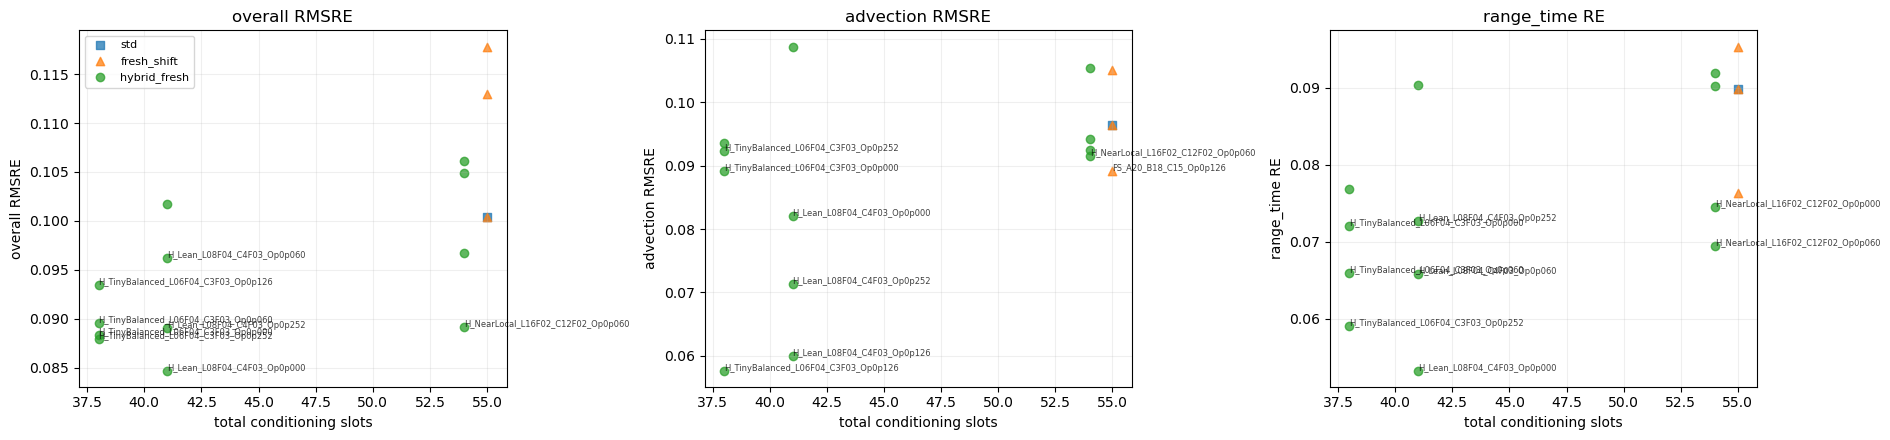

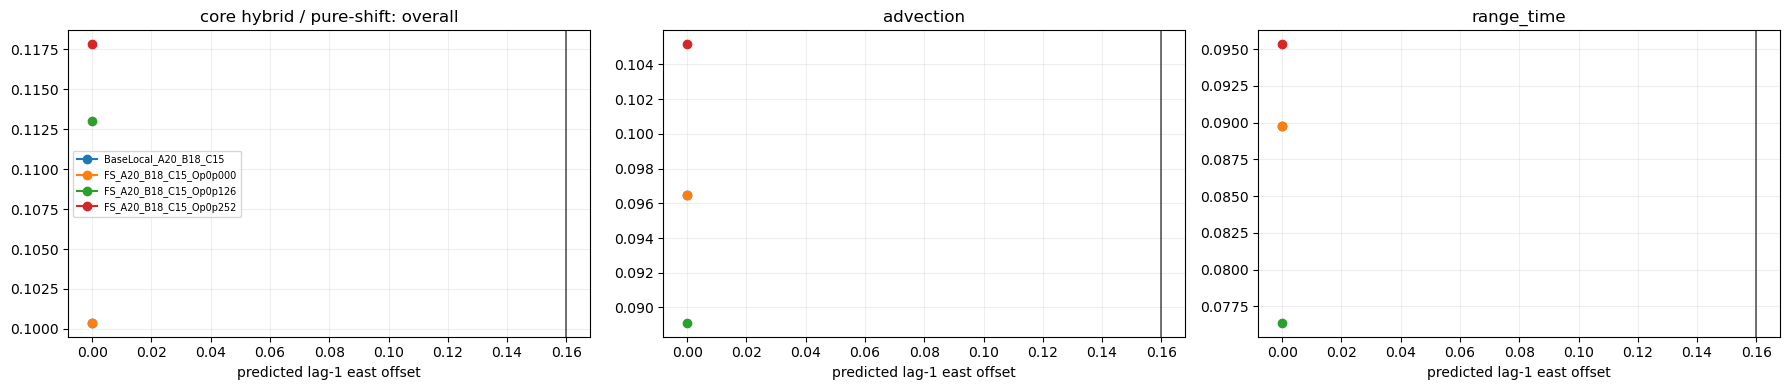

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(19, 4.5))
plot_df = mc_summary.copy()

for kernel, marker in [("std", "s"), ("fresh_shift", "^"), ("hybrid_fresh", "o")]:
    sub = plot_df[plot_df["kernel"] == kernel]
    if sub.empty:
        continue
    axes[0].scatter(sub["total_conditioning"], sub["overall_rmsre_mean"], label=kernel, marker=marker, alpha=0.75)
    axes[1].scatter(sub["total_conditioning"], sub["advec_rmsre_mean"], label=kernel, marker=marker, alpha=0.75)
    axes[2].scatter(sub["total_conditioning"], sub["range_time_re_mean"], label=kernel, marker=marker, alpha=0.75)

for ax, title, ycol in zip(
    axes,
    ["overall RMSRE", "advection RMSRE", "range_time RE"],
    ["overall_rmsre_mean", "advec_rmsre_mean", "range_time_re_mean"],
):
    ax.set_xlabel("total conditioning slots")
    ax.set_ylabel(title)
    ax.grid(alpha=0.2)
    ax.set_title(title)
    # Label top few efficient candidates by overall rank.
    for _, r in plot_df.sort_values(ycol).head(8).iterrows():
        ax.annotate(
            r["model"].replace("Hybrid_", "H_").replace("FreshShift_", "FS_"),
            (r["total_conditioning"], r[ycol]),
            fontsize=6,
            alpha=0.75,
        )
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

# Offset sensitivity for the requested core hybrid plus pure-shift baseline.
focus = mc_summary[
    mc_summary["model"].str.contains("Core_L10F06_C6F04", na=False)
    | mc_summary["model"].str.contains("FreshShift_A20_B18_C15", na=False)
    | mc_summary["model"].eq("BaseLocal_A20_B18_C15")
].copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for model, sub in focus.groupby("model", sort=False):
    if sub["pred_lag1_lon_offset"].nunique() > 1:
        sub = sub.sort_values("pred_lag1_lon_offset")
        x = sub["pred_lag1_lon_offset"]
    else:
        x = [0.0] * len(sub)
    label = model.replace("Hybrid_", "H_").replace("FreshShift_", "FS_")
    axes[0].plot(x, sub["overall_rmsre_mean"], marker="o", label=label)
    axes[1].plot(x, sub["advec_rmsre_mean"], marker="o", label=label)
    axes[2].plot(x, sub["range_time_re_mean"], marker="o", label=label)
for ax in axes:
    ax.axvline(abs(DEFAULT_TRUE_ADVEC_LON), color="black", linewidth=1.1, alpha=0.7)
    ax.grid(alpha=0.2)
    ax.set_xlabel("predicted lag-1 east offset")
axes[0].set_title("core hybrid / pure-shift: overall")
axes[1].set_title("advection")
axes[2].set_title("range_time")
axes[0].legend(fontsize=7)
plt.tight_layout()
plt.show()


## Diagnostic Decision Rule


In [22]:
print("Decision rule:")
print("1. BaseLocal_A20_B18_C15 is the original local-structure baseline: same-location anchors plus local lag footprints.")
print("2. FreshShift_A20_B18_C15 uses the same nominal 20/18/15 lag budget but reselects lagged neighbors around the predicted upstream center.")
print("3. Hybrid candidates test whether a smaller set, e.g. same + local10 + fresh6 and same + local6 + fresh4, can match or beat the two baselines.")
print("4. For true advec_lon=-0.16, offset=0.00 tests no-shift misspecification; 0.06 tests the near no-shift/half-cell edge; 0.126 tests the one-cell representable shift; 0.252 tests over-shift misspecification.")
print("5. A candidate is compelling only if it is competitive on loss/overall RMSRE and does not sacrifice advec_lon/range_time recovery.")
display(spec_df[[
    "limit_A", "lag1_local_count", "lag1_fresh_count", "lag2_local_count", "lag2_fresh_count",
    "kernel", "pred_lag1_lon_offset", "total_conditioning", "allocation",
]])


Decision rule:
1. BaseLocal_A20_B18_C15 is the original local-structure baseline: same-location anchors plus local lag footprints.
2. FreshShift_A20_B18_C15 uses the same nominal 20/18/15 lag budget but reselects lagged neighbors around the predicted upstream center.
3. Hybrid candidates test whether a smaller set, e.g. same + local10 + fresh6 and same + local6 + fresh4, can match or beat the two baselines.
4. For true advec_lon=-0.16, offset=0.00 tests no-shift misspecification; 0.06 tests the near no-shift/half-cell edge; 0.126 tests the one-cell representable shift; 0.252 tests over-shift misspecification.
5. A candidate is compelling only if it is competitive on loss/overall RMSRE and does not sacrifice advec_lon/range_time recovery.


,limit_A,lag1_local_count,lag1_fresh_count,lag2_local_count,lag2_fresh_count,kernel,pred_lag1_lon_offset,total_conditioning,allocation
local_baseline::BaseLocal_A20_B18_C15,20,18,0,15,0,std,0.0,55,original local-structure baseline: 20/18/15
fresh_shift_baseline::FreshShift_A20_B18_C15_Op0p000,20,0,18,0,15,fresh_shift,0.0,55,pure fresh shifted-center baseline: 20/18/15
fresh_shift_baseline::FreshShift_A20_B18_C15_Op0p126,20,0,18,0,15,fresh_shift,0.126,55,pure fresh shifted-center baseline: 20/18/15
fresh_shift_baseline::FreshShift_A20_B18_C15_Op0p252,20,0,18,0,15,fresh_shift,0.252,55,pure fresh shifted-center baseline: 20/18/15
hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C12F02_Op0p000,20,16,2,12,2,hybrid_fresh,0.0,54,B=same+local16+fresh2; C=same+local12+fresh2; ...
hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C12F02_Op0p060,20,16,2,12,2,hybrid_fresh,0.06,54,B=same+local16+fresh2; C=same+local12+fresh2; ...
hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C12F02_Op0p126,20,16,2,12,2,hybrid_fresh,0.126,54,B=same+local16+fresh2; C=same+local12+fresh2; ...
hybrid_budget_sweep::Hybrid_NearLocal_L16F02_C12F02_Op0p252,20,16,2,12,2,hybrid_fresh,0.252,54,B=same+local16+fresh2; C=same+local12+fresh2; ...
hybrid_budget_sweep::Hybrid_Lean_L08F04_C4F03_Op0p000,20,8,4,4,3,hybrid_fresh,0.0,41,B=same+local8+fresh4; C=same+local4+fresh3; of...
hybrid_budget_sweep::Hybrid_Lean_L08F04_C4F03_Op0p060,20,8,4,4,3,hybrid_fresh,0.06,41,B=same+local8+fresh4; C=same+local4+fresh3; of...


## Interpretation

Read this notebook as a focused robustness test for stronger advection, not a full budget-frontier sweep.

Useful comparisons:

- `BaseLocal_A20_B18_C15` vs `FreshShift_A20_B18_C15_O0p000/O0p126/O0p252`: does pure shifted-center help only when the offset is plausible, and how badly does no-shift or over-shift hurt?
- `BaseLocal_A20_B18_C15` vs `Hybrid_NearLocal_L16F02_C12F02_*`: does adding only two fresh shifted-center points per lag improve the mostly-local strategy under offset misspecification?
- `Hybrid_NearLocal_*` vs `Hybrid_Lean_*` vs `Hybrid_TinyBalanced_*`: how much budget can be removed while preserving `advec_lon`, `range_time`, and loss stability?
- `O0p000` vs `O0p060` vs `O0p126` vs `O0p252`: whether no offset, conservative under-shift, one-cell representable shift, or excessive over-shift is safest when the actual advection is `0.16`.

A strong result would be a hybrid candidate with total conditioning below 55 that is competitive with the local baseline on loss/overall RMSRE while improving or preserving `advec_lon`, `advec_lat`, and `range_time` recovery. The over-shift case should be read as a failure-mode check, not as a recommended strategy.
